# Setup

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [21]:
from eyewire2_functional_analysis import data_loader

data_root = "../../../data"
data_folder = f"{data_root}/preprocessed-data"
morph_folder = f"{data_root}/morphological-data"

In [4]:
print(sorted(os.listdir(morph_folder)))

['Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv', 'roi_mapping_2p_to_em.csv']


In [5]:
df_rois, df_fields, df_outline = data_loader.load_all_dfs(data_folder)

df = data_loader.load_df_rois_morph(
    morph_folder=morph_folder,
    morph_spreadsheet_filename='Eyewire II Proofread Cells Master List - All Cells 2026-03-17.csv',
    nuc_col_master='Final NucID',
    seg_col_master=(
        'Updated Seg ID\n(Feb 04, 2026)\nIF YOU UPDATE THIS COLUMN, ALSO UPDATE Final SegID!',
        'Updated Seg ID (Sept 2)',
        'Final SegID'),
    df_rois=df_rois,
)

## Stimuli

In [6]:
chirp_stimulus = np.load(f"{data_root}/stimuli/chirp_stimulus_ms.npy")

In [7]:
# You have to run mc_to_numpy.py first, before loading the mc array

mc15 = np.load(f"{data_root}/stimuli/mc_arrays/MC15.npy")
assert mc15.shape[0] == 123 * 5 * 30
mc15.shape

(18450, 56, 56, 3)

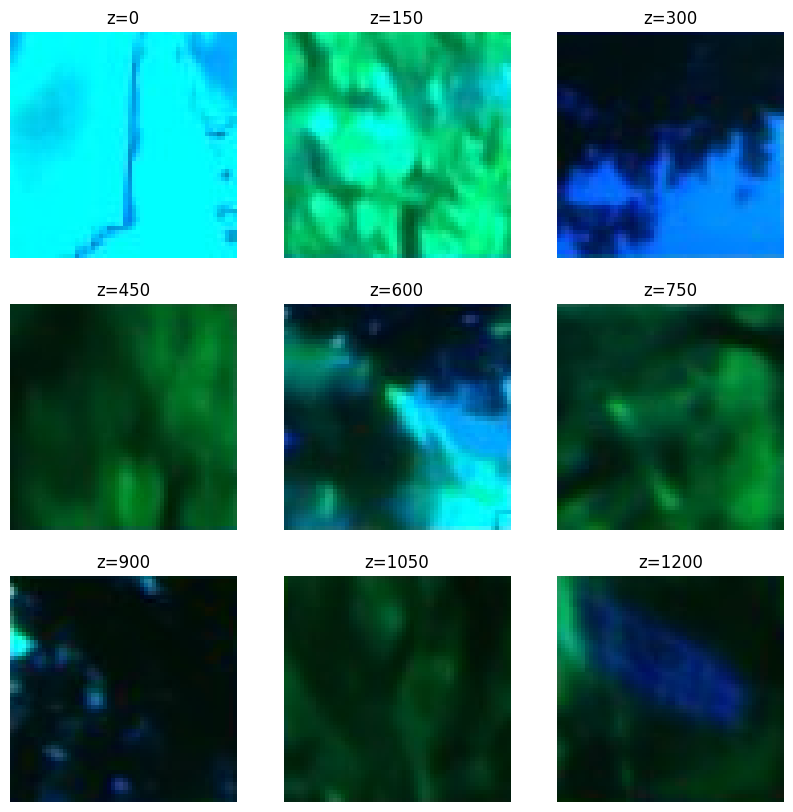

In [8]:
fig, axs = plt.subplots(3, 3, figsize=(10, 10))

for i, ax in enumerate(axs.flat):
    frame = i * 150
    ax.set(xticks=[], yticks=[], title=f"z={frame}")
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')

## Skeleton

In [9]:
skel_dir = os.path.join(data_root, 'swc')
swc_files = [f for f in os.listdir(skel_dir) if f.endswith('.swc')]
print(len(swc_files))

368


In [10]:
example_cell = {
    'nuc_id': "720575940567697697",
    'seg_id': "720575940559143627",
}

In [11]:
import skeliner as sk

skel = sk.io.load_swc(os.path.join(skel_dir, f"{example_cell['seg_id']}.swc"))

# Plot

In [12]:
from eyewire2_functional_analysis.style import set_rc_params

set_rc_params(notebook_dpi=None)

In [13]:
from eyewire2_functional_analysis import plot

In [14]:
fig_dir = './figures/'
os.makedirs(fig_dir, exist_ok=True)

## Overview

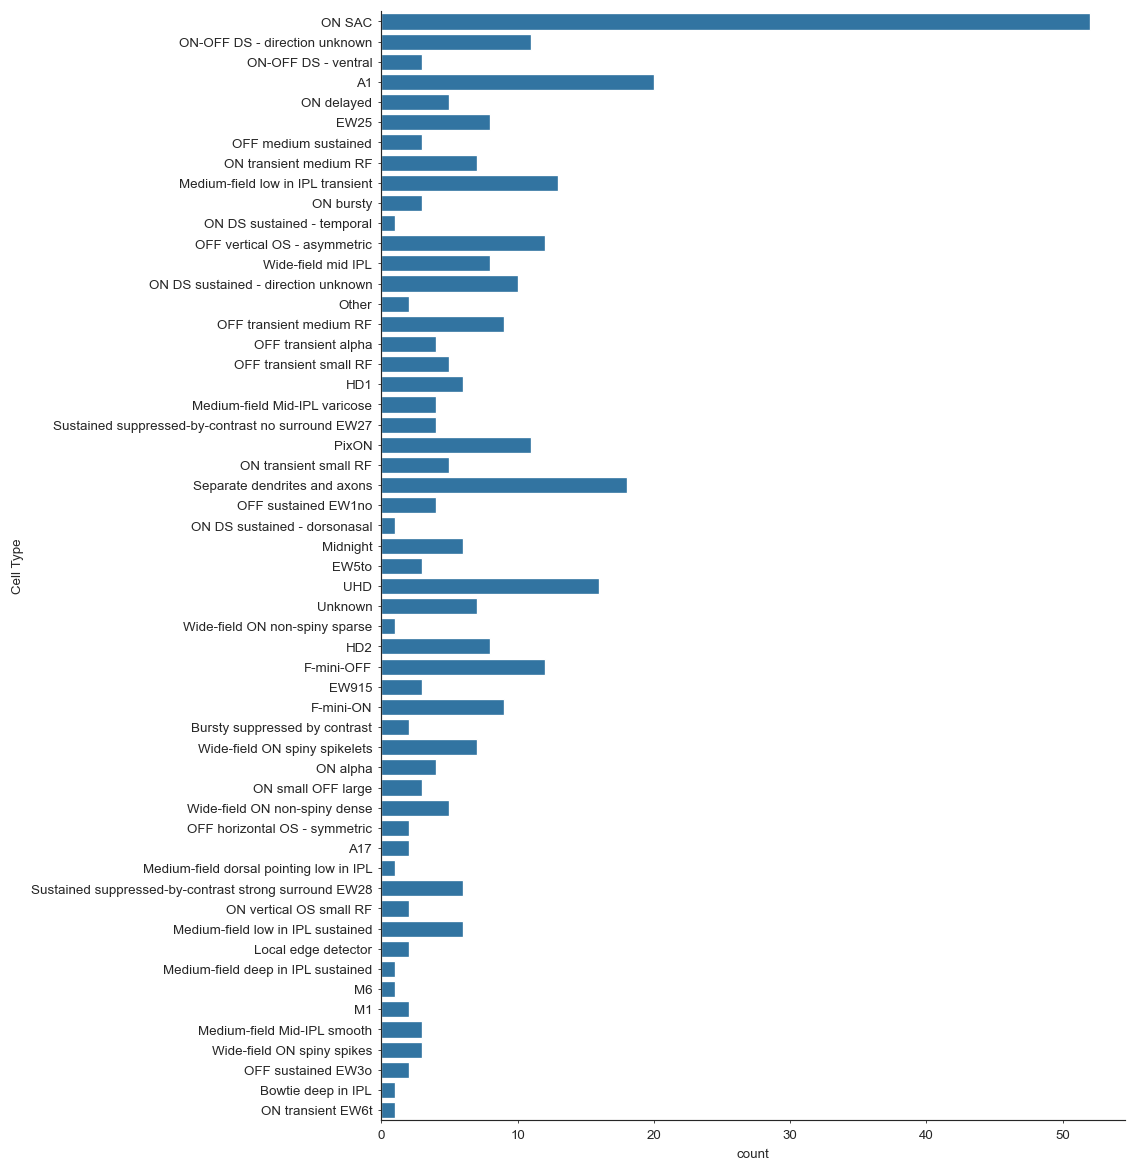

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(8, 12))
sns.countplot(ax=ax, data=df, y='Cell Type')
plt.show()

## Retina outline

In [16]:
tif_folder = f'{data_root}/R11'
em_fields_folder = f'{data_root}/em-fields'

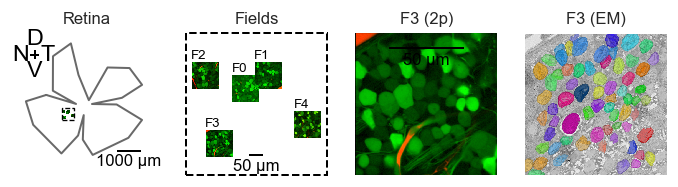

In [17]:
from eyewire2_functional_analysis.plot import plot_retina_orientation, plot_scale_bar, make_square_bounding_box, \
    add_rect, get_extent
import tifffile
import matplotlib.image as mpimg

color_crop = 'k'

fig, axs = plt.subplot_mosaic(
    """
    ABCD
    """,
    figsize=(7, 2),
)

for name, ax in axs.items():
    ax.axis('off')
    if name not in ['H', 'G']:
        ax.set_aspect('equal')

xmin, xmax, ymin, ymax = make_square_bounding_box(
    df_fields['field_temporal_nasal_pos_um'], df_fields['field_ventral_dorsal_pos_um'])

box_xlim = (xmin - 70, xmax + 70)
box_ylim = (ymin - 50, ymax + 90)

j = 0
ax = axs["A"]
ax.set_title('Retina')
ax.set(xlim=(-3000, 3000), ylim=(-3000, 3000))
ax.plot(np.append(df_outline['temporal_nasal_pos_um'].values[1:], df_outline['temporal_nasal_pos_um'].values[1]),
        np.append(df_outline['ventral_dorsal_pos_um'].values[1:], df_outline['ventral_dorsal_pos_um'].values[1]),
        c='dimgray', ls='-')

for i, row in df_fields.iterrows():
    field = int(row['field'][-1])
    extent = get_extent(row[f'ch{j}_average'], row['pixel_size_um'], row['field_temporal_nasal_pos_um'],
                        row['field_ventral_dorsal_pos_um'])
    im = tifffile.imread(os.path.join(tif_folder, f'{field}.tif'))
    ax.imshow(im, extent=extent, interpolation='none')

add_rect(ax, box_xlim, box_ylim, color_crop, linewidth=0.8)
plot_retina_orientation(ax=ax, tdist=50, x0=-2200, y0=2100, size=400)
plot_scale_bar(ax=ax, x0=1800, y0=-2000, size=1000, tdist=70)

ax = axs["B"]
ax.set_title('Fields')
for i, frow in df_fields.iterrows():
    field = int(frow['field'][-1])
    extent = get_extent(frow[f'ch{j}_average'], frow['pixel_size_um'], frow['field_temporal_nasal_pos_um'],
                        frow['field_ventral_dorsal_pos_um'])
    im = tifffile.imread(os.path.join(tif_folder, f'{field}.tif'))
    ax.imshow(im, extent=extent, interpolation='none')

    ax.text(frow['field_temporal_nasal_pos_um'] - 50, frow['field_ventral_dorsal_pos_um'] + 50,
            "F" + str(field), c='k', va='bottom', ha='left')

ax.set(xlim=box_xlim, ylim=box_ylim)
add_rect(ax, box_xlim, box_ylim, color_crop)
plot_scale_bar(ax=ax, x0=np.mean(box_xlim), y0=box_ylim[0] + 70, size=50, tdist=10)

ax = axs["C"]
field = 3
ax.set_title(f'F{field} (2p)')
frow = df_fields[df_fields.field == f'GCL{field}'].iloc[0]
extent = get_extent(frow[f'ch{j}_average'], frow['pixel_size_um'], frow['field_temporal_nasal_pos_um'],
                    frow['field_ventral_dorsal_pos_um'])
im = tifffile.imread(os.path.join(tif_folder, f'{field}.tif'))
ax.imshow(im, extent=extent, interpolation='none')
plot_scale_bar(ax=ax, x0=np.mean(extent[:2]), y0=extent[2] + 0.9 * np.diff(extent[2:]), size=50, tdist=3)

ax = axs["D"]
ax.set_title(f'F{field} (EM)')
frow = df_fields[df_fields.field == f'GCL{field}'].iloc[0]
im = mpimg.imread(os.path.join(em_fields_folder, f'{field}_v2.png'))
ax.imshow(im, interpolation='none')

plt.savefig(os.path.join(fig_dir, 'fig4abcd.svg'))

## Example cell - Skeleton

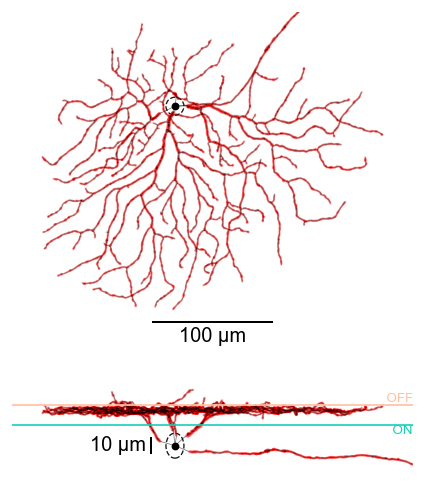

In [18]:
from eyewire2_functional_analysis.skeleton import rotate_skel

skel_rot = rotate_skel(skel, rotation_deg=150)

xmax, ymax, zmax = np.max(skel_rot.nodes[skel_rot.ntype == 3], axis=0)
xmin, ymin, zmin = np.min(skel_rot.nodes[skel_rot.ntype == 3], axis=0)

xlim = (xmin - 10, xmax + 10)
ylim = (ymin - 25, ymax + 25)
zlim = (zmin - 20, zmax + 5)

fig, axs = plt.subplots(2, 1, figsize=(4, 5), height_ratios=(5, 1))

ax = axs[0]
sk.plot.projection(skel_rot, ax=ax, xlim=ylim, ylim=xlim, plane='yx', draw_cylinders=False)
plot.plot_scale_bar(ax=ax, x0=np.mean(ylim), y0=xlim[0], size=100, text=True, unit='µm', tdist=4, fontsize=12)

ax = axs[1]
sk.plot.projection(skel_rot, ax=ax, xlim=ylim, ylim=zlim, plane='yz')
plot.plot_sac_lines(ax, ylim)
ax.set_aspect('auto', 'box')
plot_scale_bar(ax=ax, x0=skel_rot.soma.center[1] - 20, y0=skel_rot.soma.center[2],
               size=10, text=True, unit='µm', tdist=-50, fontsize=12, orientation='v')

for ax in axs:
    ax.axis('off')

plt.savefig(os.path.join(fig_dir, 'fig4f.svg'))

## Example cell - Responses

In [19]:
row = df[df.nuc_id == example_cell['nuc_id']].iloc[0]

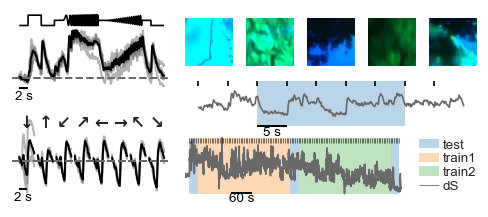

In [20]:
fig, axs = plt.subplot_mosaic(
    """
    AEFGHI
    ACCCCC
    .CCCCC
    BCCCCC
    BDDDDD
    """,
    figsize=(5, 2),
    width_ratios=(1, 0.3, 0.3, 0.3, 0.3, 0.3),
    height_ratios=(1, 0.2, 0.2, 0.2, 1),
)

ax = axs['A']
plot.plot_chirp(ax, row=row, stimulus_ms=chirp_stimulus)
ax.axis('off')
plot.plot_scale_bar(ax=ax, x0=1, y0=-0.2, size=2, text=True, unit='s', tdist=0.05, fontsize=8)

ax = axs['B']
plot.plot_bar(ax, row=row, annotate_symbols=True)
plot.plot_scale_bar(ax=ax, x0=1, y0=-0.7, size=2, text=True, unit='s', tdist=0.05, fontsize=8)
ax.axis('off')

ax = axs['D']
mc_trace = row.mc_trace
mc_time = np.arange(mc_trace.size) * row.mc_trace_dt + row.mc_trace_t0
mc_tt = row.mc_triggertimes
mc_tt = np.append(mc_tt, mc_tt[-1] + np.median(np.diff(mc_tt)))
mc_ylim = (mc_trace.min(), mc_trace.max())

ax.axis('off')
for test_i in [0, 59, 118]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C0', alpha=0.3, lw=0,
                    label='test' if test_i == 0 else '_')

ax.fill_between(x=[mc_tt[5], mc_tt[5 + 54]], y1=mc_ylim[0], y2=mc_ylim[1], color='C1', alpha=0.3, lw=0, label='train1')
ax.fill_between(x=[mc_tt[59 + 5], mc_tt[59 + 54 + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C2', alpha=0.3, lw=0,
                label='train2')

ax.plot(mc_time, mc_trace, c='dimgray', lw=1)
ax.vlines(mc_tt, ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k', linestyles='-', lw=0.3,
          label='dS')

ax.legend(bbox_to_anchor=(0.8, 0.5), loc='center left', borderaxespad=0., frameon=False, handlelength=1.5, )
plot.plot_scale_bar(ax=ax, x0=np.mean(mc_tt[:len(mc_tt) // 2]), y0=mc_ylim[0] + 3, size=60, text=True, unit='s',
                    tdist=1, fontsize=8)
ax.set_xlim(mc_time[0], mc_time[-1] + (mc_time[-1] - mc_time[0]) * 0.35)

ax = axs['C']
tlim_test2 = (mc_tt[59] - mc_tt[59 + 5])
ilim = (mc_time >= mc_tt[59] - 10) & (mc_time <= mc_tt[59 + 5] + 10)
ax.axis('off')
ax.plot(mc_time[ilim], mc_trace[ilim], c='dimgray', lw=1)
for test_i in [59]:
    ax.fill_between(x=[mc_tt[test_i], mc_tt[test_i + 5]], y1=mc_ylim[0], y2=mc_ylim[1], color='C0', alpha=0.3, lw=0,
                    label='test' if test_i == 0 else '_')

ax.vlines(mc_tt[59 - 2:59 + 5 + 2], ymin=mc_ylim[1] - np.diff(mc_ylim) * 0.1, ymax=mc_ylim[1], colors='k',
          linestyles='-', lw=1)
plot.plot_scale_bar(ax=ax, x0=mc_tt[59] + 2.5, y0=mc_ylim[0] + 2, size=5, text=True, unit='s', tdist=1, fontsize=8)

for i in range(5):
    seq = 59 + i
    frame = seq * 30 * 5
    ax = axs[['E', 'F', 'G', 'H', 'I'][i]]
    ax.set(xticks=[], yticks=[])
    ax.imshow(mc15[frame, :, :])
    ax.axis('off')

plt.savefig(os.path.join(fig_dir, 'fig4g.svg'))